# Kinematic spatial-gradient quickstart

This data-free example constructs four synthetic donors, each with an oriented spatial coordinate and three expression profiles. It then runs the same per-donor quantile binning, Gaussian smoothing, and per-gene slope primitive used in the manuscript.

The output is a spatial gradient. Interpreting its sign as a net-production direction additionally requires a stationary position-conditioned expression field and positive mean cell displacement along the oriented axis.

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Work when launched from either the repository root or examples/.
repo_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src" / "sgd").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this notebook from inside the SGD repository.")
sys.path.insert(0, str(repo_root / "src"))

from sgd.gradient import per_gene_gradient, quantile_bin_per_donor_pool

## 1. Build an expression matrix and spatial coordinates

`portal_marker` decreases along the oriented axis, `central_marker` increases, and `mid_axis_gene` has a non-monotone peak. The last profile illustrates why the slope should be inspected together with the monotonicity diagnostic and the binned curve.

In [2]:
rng = np.random.default_rng(7)
donor_ids = [f"D{i}" for i in range(1, 5)]
spots_per_donor = 120

rows = []
sample_ids = []
coordinates = []
for donor_index, donor in enumerate(donor_ids):
    s = np.linspace(0.0, 1.0, spots_per_donor)
    s = np.clip(s + rng.normal(0.0, 0.012, spots_per_donor), 0.0, 1.0)
    donor_shift = rng.normal(0.0, 0.08, 3)
    expression = np.column_stack([
        2.8 - 1.6 * s,
        1.0 + 2.0 * s,
        0.8 + 1.8 * np.exp(-((s - 0.5) / 0.18) ** 2),
    ])
    expression += donor_shift + rng.normal(0.0, 0.18, expression.shape)
    rows.append(np.clip(expression, 0.0, None))
    sample_ids.extend([donor] * spots_per_donor)
    coordinates.extend(s)

gene_names = ["portal_marker", "central_marker", "mid_axis_gene"]
adata = ad.AnnData(
    X=np.vstack(rows),
    obs=pd.DataFrame(
        {"sample_id": sample_ids, "s": coordinates},
        index=[f"spot_{i}" for i in range(len(sample_ids))],
    ),
    var=pd.DataFrame(index=gene_names),
)
adata

AnnData object with n_obs × n_vars = 480 × 3
    obs: 'sample_id', 's'

## 2. Estimate per-gene gradients

Binning is performed separately within each donor before donor-bin means are pooled. This prevents donors with more spots from dominating the cohort profile.

In [3]:
smoothed_expression, bin_centres, cells_per_bin, _ = quantile_bin_per_donor_pool(
    adata, s_col="s", sample_col="sample_id", n_bins=20
)
gradient = per_gene_gradient(smoothed_expression, bin_centres)

raw_s = adata.obs["s"].to_numpy()
raw_expression = np.asarray(adata.X)
raw_pearson = [np.corrcoef(raw_s, raw_expression[:, j])[0, 1] for j in range(adata.n_vars)]
diagnostics = pd.DataFrame(
    {
        "slope": gradient["slope"],
        "mean_local_derivative": gradient["bin_mean_dgds"],
        "monotonicity": gradient["monotonicity"],
        "raw_pearson_r": raw_pearson,
        "slope_correlation_sign_agree": (
            np.sign(gradient["slope"]) == np.sign(raw_pearson)
        ),
    },
    index=gene_names,
)
diagnostics.round(3)

,slope,mean_local_derivative,monotonicity,raw_pearson_r,slope_correlation_sign_agree
portal_marker,-1.578,-1.527,1.00,-0.929,True
central_marker,2.060,1.987,1.00,0.958,True
mid_axis_gene,-0.007,-0.071,0.55,-0.002,True


`monotonicity` is the fraction of local derivatives having the dominant sign. Values near 1 support a single directional summary; values near 0.5 flag a profile whose slope averages over local sign changes.

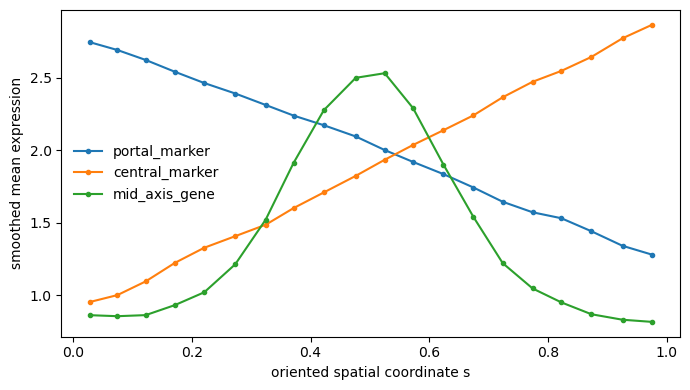

Quickstart checks passed.


In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for gene_index, gene in enumerate(gene_names):
    ax.plot(bin_centres, smoothed_expression[:, gene_index], marker="o", ms=3, label=gene)
ax.set(xlabel="oriented spatial coordinate s", ylabel="smoothed mean expression")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

assert cells_per_bin.min() > 0
assert diagnostics.loc["portal_marker", "slope"] < 0
assert diagnostics.loc["central_marker", "slope"] > 0
assert diagnostics.loc["mid_axis_gene", "monotonicity"] < 0.75
print("Quickstart checks passed.")